In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
# [Cell: 0db7a439] Проверяем формат столбцов
print(df.info()) # Выводит типы данных и наличие пропусков 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB
None


Сразу переведем столбец "Дата" в правильный формат

In [5]:
# [Cell: 317e1a0b] Переведем столбец "Дата" в формат datetime
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')

Вывести несколько первых строк сгруппированных данных

In [7]:
print(grouped_df.head())

        Дата  Количество продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


Нарисуйте график продаж у `grouped_df`

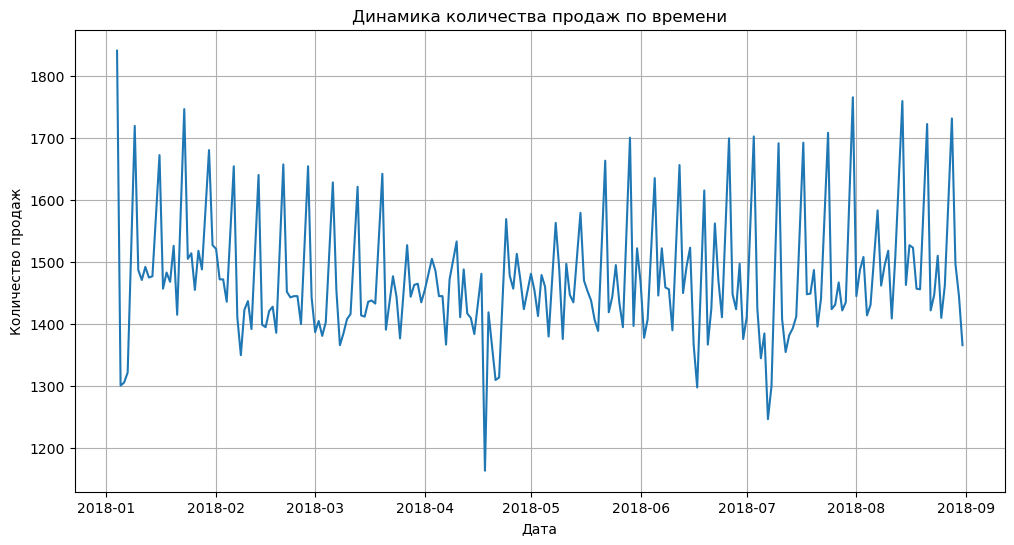

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=grouped_df, x='Дата', y='Количество продаж')
plt.title('Динамика количества продаж по времени')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
ренд: Стабильно горизонтальный, без явного долгосрочного роста или падения за 8 месяцев 2018 года.

Сезонность: Сильная еженедельная цикличность — регулярные резкие пики (вероятно, выходные) и глубокие спады в будни.

Волатильность: Высокая — продажи постоянно колеблются между 1300 и 1800 единицами.

Аномалии:

Пик: Рекордные продажи в начале января (>1800).

Провал: Критическое падение в середине апреля (ниже 1200), что может указывать на технический сбой или пустые склады.


Вывод: Бизнесу нужно сглаживать пиковые нагрузки на логистику и разобраться с причинами глубокого провала в апреле

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
max_outlier_row = df.loc[df['Количество'].idxmax()]

print("Строка с максимальным выбросом по количеству продаж:")
print(max_outlier_row)

Строка с максимальным выбросом по количеству продаж:
Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
summer_wed_filter = (
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.dayofweek == 2)
)

top_product = (
    df[summer_wed_filter]
    .groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

print("Топовый товар по средам за лето у 3 склада:")
print(top_product)

Топовый товар по средам за лето у 3 склада:
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

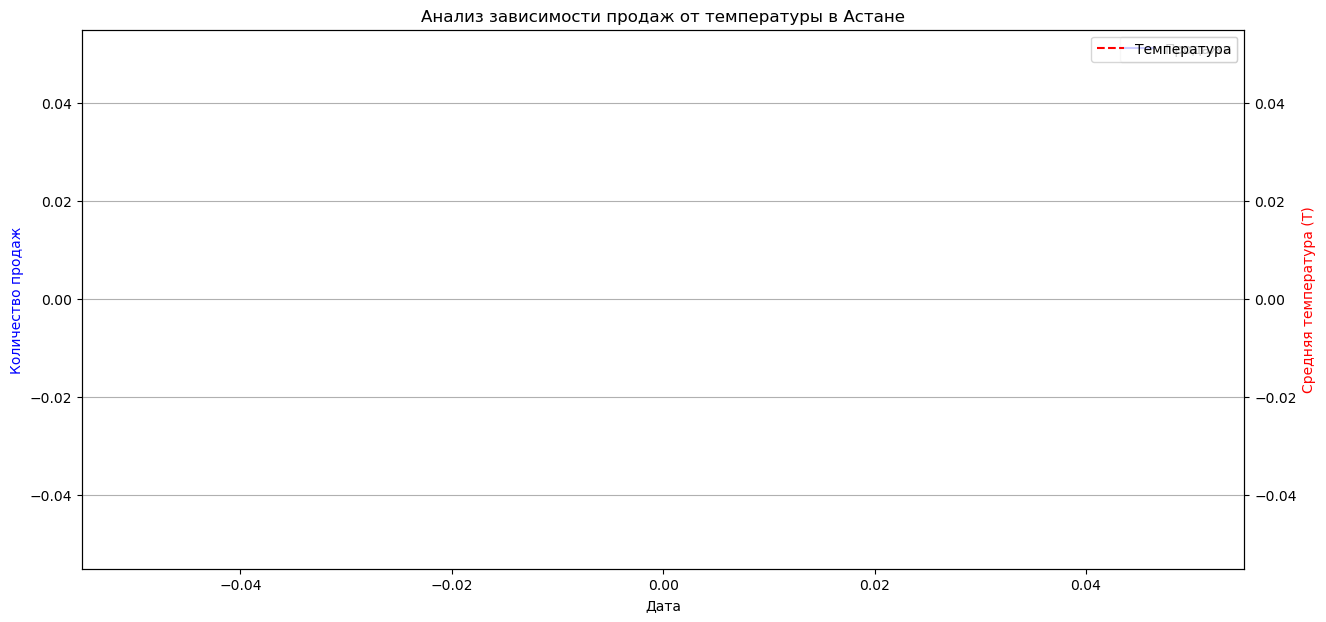

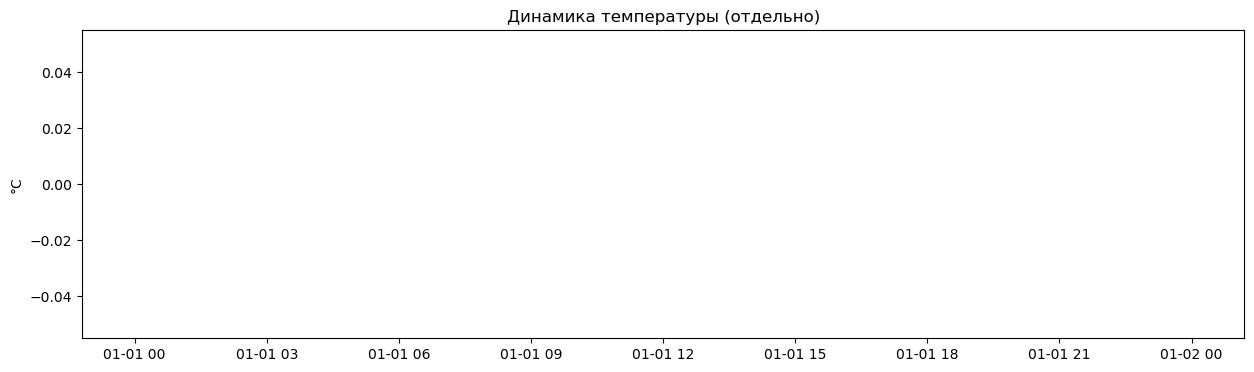

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_weather = pd.read_csv(
    's86aU7iXQSSrbn0', 
    sep=';', 
    comment='#', 
    encoding='utf-8',
    index_col=False
)

df_weather.columns = [c.replace('"', '') for c in df_weather.columns]

time_col = 'Местное время в Астане'
df_weather[time_col] = pd.to_datetime(df_weather[time_col], dayfirst=True)
df_weather['Дата'] = df_weather[time_col].dt.normalize()

daily_temp = df_weather.groupby('Дата')['T'].mean().reset_index()

merged_df = pd.merge(grouped_df, daily_temp, on='Дата', how='inner')

fig, ax1 = plt.subplots(figsize=(15, 7))

sns.lineplot(data=merged_df, x='Дата', y='Количество продаж', ax=ax1, color='blue', label='Продажи')
ax1.set_ylabel('Количество продаж', color='blue')

ax2 = ax1.twinx()
sns.lineplot(data=merged_df, x='Дата', y='T', ax=ax2, color='red', label='Температура', linestyle='--')
ax2.set_ylabel('Средняя температура (T)', color='red')

plt.title('Анализ зависимости продаж от температуры в Астане')
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(daily_temp['Дата'], daily_temp['T'], color='orange')
plt.title('Динамика температуры (отдельно)')
plt.ylabel('°C')
plt.show()